In [1]:
!pip install yfinance

In [2]:
!pip install tensorflow

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Define Parameters and Fetch Data

TICKER = 'AAPL'
START_DATE = '2018-01-01'
END_DATE = '2025-10-10'
TIME_STEP = 180 # Number of previous days to look at for prediction

# Fetch data using yfinance
print(f"Fetching data for {TICKER} from {START_DATE} to {END_DATE}...")
data = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Keep only the 'Close' price for the basic model
df = data[['Close']]

print(f"Data fetched. Total rows: {len(df)}")
print(df.head())

Fetching data for AAPL from 2018-01-01 to 2025-10-10...


C:\Users\Home\AppData\Local\Temp\ipykernel_4380\90302597.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Data fetched. Total rows: 1954
Price           Close
Ticker           AAPL
Date                 
2018-01-02  40.380993
2018-01-03  40.373966
2018-01-04  40.561501
2018-01-05  41.023304
2018-01-08  40.870930


In [4]:
# 2.1. Normalize Data
print("\n--- 2.1. Normalizing Data ---")

# Initialize and fit the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# The scaled_data array is what we feed into the LSTM preparation
print(f"Data scaled successfully. Shape: {scaled_data.shape}")

# 2.2. Create Timesteps (Sequences) 
print("\n--- 2.2. Creating Timesteps (X, y sequences) ---")

X, y = [], []

# Loop to create sequences of 60 historical prices (X) and the next day's price (y)
for i in range(TIME_STEP, len(scaled_data)):
    # X: 60 prices before index i
    X.append(scaled_data[i-TIME_STEP:i, 0])
    # y: Price at index i (the target)
    y.append(scaled_data[i, 0])

# Convert lists to NumPy arrays
X, y = np.array(X), np.array(y)

# Reshape X for LSTM: [samples, timesteps, features]
# Features is 1 because we only use the 'Close' price
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"X shape (samples, timesteps, features): {X.shape}")
print(f"y shape (targets): {y.shape}")

# 2.3. Train-Test Split
print("\n--- 2.3. Splitting Data (80% Train, 20% Test) ---")

# Calculate split index
train_size = int(len(X) * 0.8)

# Split data chronologically
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training Samples (X_train): {X_train.shape[0]}")
print(f"Testing Samples (X_test): {X_test.shape[0]}")


--- 2.1. Normalizing Data ---
Data scaled successfully. Shape: (1954, 1)

--- 2.2. Creating Timesteps (X, y sequences) ---
X shape (samples, timesteps, features): (1774, 180, 1)
y shape (targets): (1774,)

--- 2.3. Splitting Data (80% Train, 20% Test) ---
Training Samples (X_train): 1419
Testing Samples (X_test): 355


In [5]:
# 3.1. Define the Model Architecture 

# Initialize the Sequential model
model = Sequential()

# Layer 1: LSTM with 50 units. Input shape is (timesteps, features).
# Setting return_sequences=True allows stacking another LSTM layer.
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1) # (TIME_STEP, 1 feature)
))

# Optional Dropout to prevent overfitting
model.add(Dropout(0.2))

# Layer 2: Another LSTM layer (50 units)
# return_sequences=False because this is the last LSTM layer before the output.
model.add(LSTM(units=50, return_sequences=False))

# Optional Dropout
model.add(Dropout(0.2))

# Output Layer: Dense layer with 1 unit (to predict a single price)
model.add(Dense(units=1))

# --- 3.2. Compile the Model ---
print("\nCompiling the model...")
model.compile(
    optimizer='adam', # Excellent general-purpose optimizer
    loss='mean_squared_error' # Standard loss for regression problems
)

# Print a summary of the model layers
model.summary()


# --- 3.3. Train the Model ---
print("\nStarting model training...")

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=25,       # Number of times to iterate over the entire dataset
    batch_size=32,   # Number of samples per gradient update
    validation_split=0.1, # Use 10% of training data for internal validation
    verbose=1
)

print("\nModel training complete!")

C:\Users\Home\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Compiling the model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 180, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 180, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 232ms/step - loss: 0.0201 - val_loss: 0.0043
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - loss: 0.0021 - val_loss: 7.4058e-04
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - loss: 0.0020 - val_loss: 6.0591e-04
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 280ms/step - loss: 0.0018 - val_loss: 9.2195e-04
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - loss: 0.0017 - val_loss: 8.8898e-04
Epoch 9/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - loss: 0.0018 - val_loss: 5.8601e-04
Epoch 10/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - loss: 0.0016 - val_loss: 5.3419e-04
Epoch 11/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - loss: 0.0015 - val_loss

Making predictions on the test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step

Sample of Actual vs Predicted Prices:
   Actual Price  Predicted Price
0    181.991379       178.104141
1    185.202682       179.616547
2    186.346039       181.106979
3    188.622803       182.546112
4    188.742096       184.000000

Plotting results...


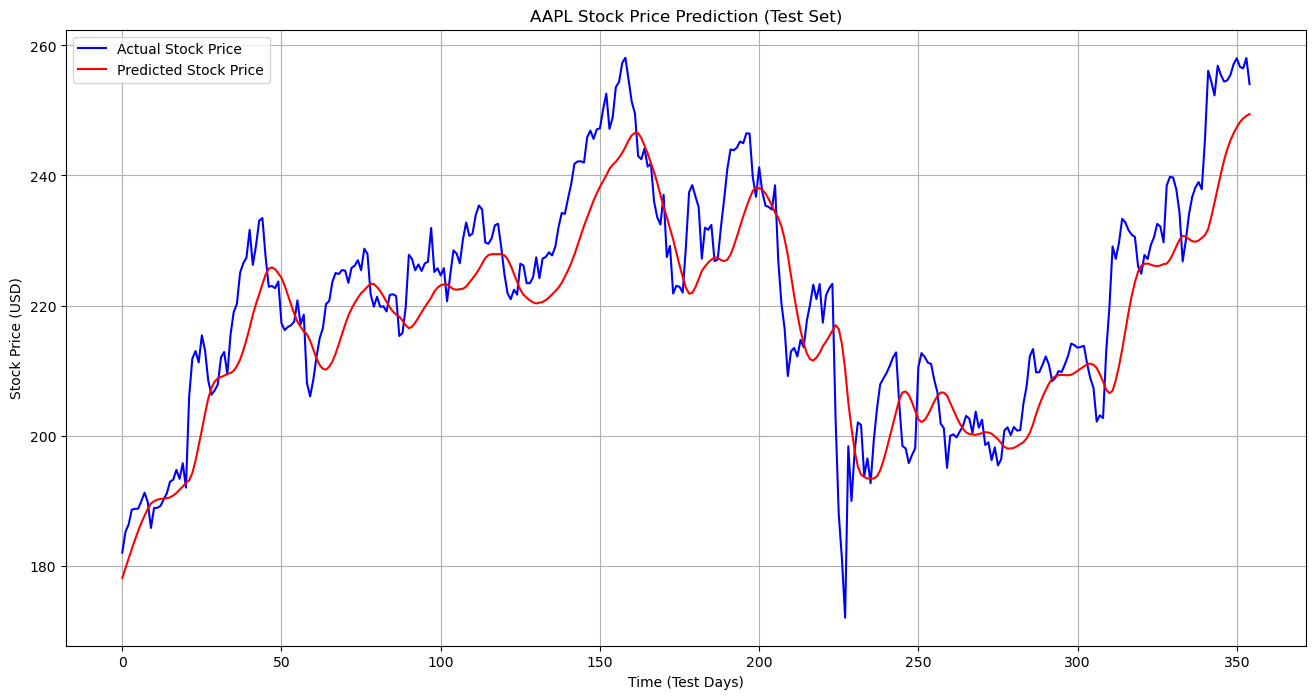


Root Mean Squared Error (RMSE): $8.56


In [6]:
# 4.1. Make Predictions 
print("Making predictions on the test set...")
# Predict scaled prices on the test data
predicted_scaled_price = model.predict(X_test)

# 4.2. Inverse Transform (Rescale) Predictions
# The scaler was trained only on the 'Close' price, so we can use it directly.
# Rescale the predicted prices back to the original dollar values.
predicted_price = scaler.inverse_transform(predicted_scaled_price)

# Rescale the actual test target prices (y_test) for plotting.
# y_test must be reshaped into a 2D array before inverse_transform.
actual_price = scaler.inverse_transform(y_test.reshape(-1, 1))

# 4.3. Create the Final DataFrame for Comparison
# Create a DataFrame to easily compare results and get indices
comparison_df = pd.DataFrame({
    'Actual Price': actual_price.flatten(),
    'Predicted Price': predicted_price.flatten()
})

print("\nSample of Actual vs Predicted Prices:")
print(comparison_df.head())

# 4.4. Plot Predictions vs Actual
print("\nPlotting results...")

plt.figure(figsize=(16, 8))
plt.plot(actual_price, color='blue', label='Actual Stock Price')
plt.plot(predicted_price, color='red', label='Predicted Stock Price')

# Add context for better visualization
plt.title(f'{TICKER} Stock Price Prediction (Test Set)')
plt.xlabel('Time (Test Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 4.5. Calculate Root Mean Squared Error (RMSE)
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(actual_price, predicted_price))
print(f"\nRoot Mean Squared Error (RMSE): ${rmse:.2f}")

In [7]:
# 5.1. Feature Engineering with Indicators

# Re-fetch data to ensure we have Open, High, Low, and Volume for indicators
data = yf.download(TICKER, start=START_DATE, end=END_DATE)
df = data.copy()

# Calculate 20-Day Simple Moving Average (SMA)
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# Calculate RSI (We'll use a simple manual calculation or a library like 'ta' if installed)

# --- Simple Manual RSI Calculation (Standard 14-day period) ---
def calculate_rsi(series, window):
    # Calculate difference
    delta = series.diff()
    # Separate gains (positive delta) and losses (negative delta)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Calculate average gain and average loss
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()

    # Calculate Relative Strength (RS)
    rs = avg_gain / avg_loss
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'], window=14)

# Drop rows with NaN values (which are the first 20 days due to SMA/RSI calculation)
df = df.dropna()

# Select the features for the multi-variable LSTM
features = ['Close', 'SMA_20', 'RSI']
df_features = df[features]

print("\nNew Feature DataFrame Head (after dropping NaNs):")
print(df_features.head())

C:\Users\Home\AppData\Local\Temp\ipykernel_4380\2537345295.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


New Feature DataFrame Head (after dropping NaNs):
Price           Close     SMA_20        RSI
Ticker           AAPL                      
Date                                       
2018-01-30  39.140919  40.867182  26.698137
2018-01-31  39.248756  40.810570  29.049357
2018-02-01  39.330799  40.758412  30.866222
2018-02-02  37.624226  40.611548  19.614593
2018-02-05  36.684223  40.394594  16.127341


In [8]:
# 5.2. Re-Normalize and Create Sequences

# Initialize and fit the MinMaxScaler on all features
# IMPORTANT: Use a new scaler instance if you want to keep the old single-feature scaler
scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_data_multi = scaler_multi.fit_transform(df_features)

# The target column is still the 'Close' price, which is at index 0 of the scaled_data_multi
X_multi, y_multi = [], []

# Loop to create sequences (TIME_STEP=60)
for i in range(TIME_STEP, len(scaled_data_multi)):
    # X_multi: All 3 features for the last 60 timesteps
    X_multi.append(scaled_data_multi[i-TIME_STEP:i])
    # y_multi: Only the scaled 'Close' price for the current day (index 0)
    y_multi.append(scaled_data_multi[i, 0])

# Convert to NumPy arrays
X_multi, y_multi = np.array(X_multi), np.array(y_multi)

# X_multi shape is already [samples, timesteps, features] -> [X.shape[0], 60, 3]
print(f"\nMulti-Feature X shape: {X_multi.shape}")
print(f"Multi-Feature y shape: {y_multi.shape}")


# 5.3. Re-Split Data
train_size_multi = int(len(X_multi) * 0.8)

X_train_multi, X_test_multi = X_multi[:train_size_multi], X_multi[train_size_multi:]
y_train_multi, y_test_multi = y_multi[:train_size_multi], y_multi[train_size_multi:]


Multi-Feature X shape: (1755, 180, 3)
Multi-Feature y shape: (1755,)


In [9]:
# 6.1. Define the Multi-Feature Model Architecture
# The input shape is now (TIME_STEP, 3)

model_multi = Sequential()
INPUT_FEATURES = X_train_multi.shape[2] # This will be 3

# Layer 1: Update input_shape to (TIME_STEP, 3)
model_multi.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train_multi.shape[1], INPUT_FEATURES)
))
model_multi.add(Dropout(0.2))

# Layer 2: Standard LSTM
model_multi.add(LSTM(units=50, return_sequences=False))
model_multi.add(Dropout(0.2))

# Output Layer: Dense layer with 1 unit
model_multi.add(Dense(units=1))

# 6.2. Compile and Train
print("\nCompiling the Multi-Feature Model...")
model_multi.compile(optimizer='adam', loss='mean_squared_error')
model_multi.summary()

print("\nStarting Multi-Feature model training...")

history_multi = model_multi.fit(
    X_train_multi,
    y_train_multi,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nMulti-Feature Model training complete!")

C:\Users\Home\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Compiling the Multi-Feature Model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 180, 50)             │          10,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 180, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)


Starting Multi-Feature model training...
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - loss: 0.0185 - val_loss: 0.0023
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - loss: 0.0025 - val_loss: 5.6635e-04
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - loss: 0.0023 - val_loss: 5.0437e-04
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - loss: 0.0023 - val_loss: 8.8589e-04
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - loss: 0.0020 - val_loss: 6.5134e-04
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - loss: 0.0019 - val_loss: 6.4630e-04
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 9/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - loss: 0.0019 - val_loss: 5.4620e-04
Epoch 10/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step - loss: 0.0018 - val_loss: 3.6160e-04
Epoch 11/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 232ms/step - loss:

Making predictions on the test set using the multi-feature model...
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step

Sample of Actual vs Predicted Prices (Multi-Feature Model):
   Actual Price  Predicted Price (Multi-Feature)
0    188.742096                       182.066540
1    188.771927                       183.360338
2    189.935165                       184.532597
3    191.237595                       185.712208
4    189.795959                       186.952295

Root Mean Squared Error (RMSE) for Single-Feature Model: $8.56
Root Mean Squared Error (RMSE) for Multi-Feature Model: $11.08


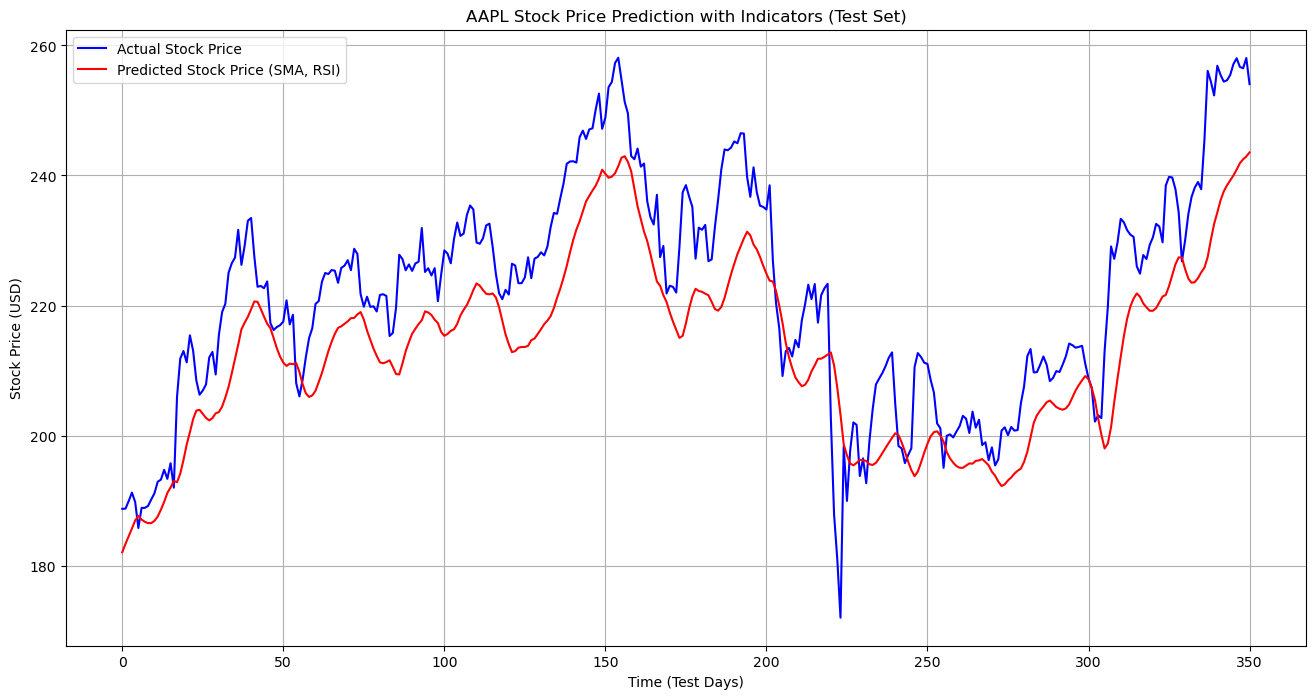

In [10]:
# 7.1. Make Predictions with Multi-Feature Model
print("Making predictions on the test set using the multi-feature model...")
# Predict scaled prices on the test data (X_test_multi)
predicted_scaled_price_multi = model_multi.predict(X_test_multi)

# 7.2. Inverse Transform (Rescale) Predictions
# Since the scaler_multi was fitted on 3 features, we must create a dummy 
# array of 3 columns to inverse transform the 1-column prediction output.

# Create a blank array with the same number of rows as predictions and 3 columns
prediction_copies_multi = np.zeros(shape=(len(predicted_scaled_price_multi), scaler_multi.n_features_in_))
# Place the predictions into the first column (where the 'Close' price was)
prediction_copies_multi[:, 0] = predicted_scaled_price_multi[:, 0]

# Inverse transform the array. It returns the actual dollar price in the first column.
predicted_price_multi = scaler_multi.inverse_transform(prediction_copies_multi)[:, 0]

# Inverse transform the actual test target prices (y_test_multi)
actual_copies_multi = np.zeros(shape=(len(y_test_multi), scaler_multi.n_features_in_))
actual_copies_multi[:, 0] = y_test_multi
actual_price_multi = scaler_multi.inverse_transform(actual_copies_multi)[:, 0]

# 7.3. Create the Final DataFrame for Comparison
comparison_df_multi = pd.DataFrame({
    'Actual Price': actual_price_multi.flatten(),
    'Predicted Price (Multi-Feature)': predicted_price_multi.flatten()
})

print("\nSample of Actual vs Predicted Prices (Multi-Feature Model):")
print(comparison_df_multi.head())

# 7.4. Calculate and Compare RMSE
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse_multi = sqrt(mean_squared_error(actual_price_multi, predicted_price_multi))

print(f"\nRoot Mean Squared Error (RMSE) for Single-Feature Model: ${rmse:.2f}")
print(f"Root Mean Squared Error (RMSE) for Multi-Feature Model: ${rmse_multi:.2f}")


# 7.5. Plot Predictions vs Actual
plt.figure(figsize=(16, 8))
plt.plot(actual_price_multi, color='blue', label='Actual Stock Price')
plt.plot(predicted_price_multi, color='red', label='Predicted Stock Price (SMA, RSI)')

plt.title(f'{TICKER} Stock Price Prediction with Indicators (Test Set)')
plt.xlabel('Time (Test Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import joblib

# Save the trained multi-feature model
print("Saving model and scaler...")
model_multi.save('lstm_model_multi.keras') 

# Save the multi-feature scaler object
joblib.dump(scaler_multi, 'scaler_multi.pkl')
print("Model and scaler saved successfully!")

Saving model and scaler...
Model and scaler saved successfully!
